# Clustering
This series of notebooks helps data scientists to forecast multiple time series by building models based on the time-series profiling, i.e identifying similar consumption profiles and building a specific model for each cluster. 

Clustering profile of time series data helps in defining the best fitting model by understanding in terms of choice of regressors (calendar variables or temperatures), forecasting algorithm (ARIMA vs Exponential smoothing) and train set (one year or just few days of data). 

The steps to clustering time series are the following:
1. Prepare data by understand the structure of the data (cross-sectional vs panel data), build a full time sequence and treating missing values
2. Indentifying intermittent time series vs smooth time series, by following an **enhanced** classification based on the Syntetos–Boylan–Croston (SBC) use of Coefficient of Variation (CV^2), Average Demand Interval (ADI) and Standard Deviation Demand Interval (SDDI) indicators
   1. Smooth, if ADI<1.32, CV^2<0.49
   2. Intermittent, if ADI>=1.32, CV^2<0.49
   3. Erratic, if ADI<1.32, CV^2>=0.49
   4. Lumpy, if ADI>=1.32, CV^2>=0.49
   5. Unforecastable time, if SDDI >= SDDI threshold, CV^2<0.49
   6. Unforecastable quantity, if SDDI >= SDDI threshold, CV^2>=0.49
3. Clustering with K-Means those time-series identified as **smooth**
   
In this notebook you will follow step 3 on clustering regular or smooth time series with k-means.


# Summary of tasks

Your task in this notebook is to identify consumption patterns that are similar to each other in order to assign the optimal model to forecast their demand​. 

After you have identified the series that is classified as "intermittent" with respect to those "regular or smooth"​, now your **goal** is to perform a k-means cluster analysis only on time series classified as regular or smooth. 

The **expected output** is to label each time series with a cluster number using k-means.

# Implementation

## Packages
Load the packages required for this notebook

In [1]:
# data elaboration functions
import pandas as pd
import numpy as np
from pathlib import Path
import os

# datetime functions
import datetime as dt

# plot functions
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# data science functions
from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# statistical functions
from scipy.stats.mstats import winsorize

## Setup & Configuration
Define configuration parameters inline (migrated from config.yaml)

In [2]:
# Time series configuration
date_var = 'WEEK_START_DT'
date_format = '%Y-%m-%d'
id = 'product_name'
unique_id = 'STORE_LOCATION_ID'
frequency = 'W'
y = 'TOTAL_NET_SALES'

# Fabric Lakehouse configuration
LAKEHOUSE_NAME = "ts_forecasting"
INPUT_TABLE = "df_final"
PROFILING_TABLE = "df_profiling"
OUTPUT_TABLE = "df_profiling_clustering"
LOCAL_FOLDER = "supermarket_net_sales"  # Local folder for fallback storage

root_path = Path.cwd().parent.parent

# Winsorizing parameters
highest = 0.05
lowest = 0.05

# Clustering parameters
try_clusters = 5

# Set seed for reproducibility
sample_seed_kmeans = 789

print("Configuration loaded:")
print(f"  - Date variable: {date_var}")
print(f"  - Target variable: {y}")
print(f"  - Unique ID: {unique_id}")
print(f"  - ID: {id}")
print(f"  - Max clusters to try: {try_clusters}")
print(f"  - Winsorizing: highest={highest}, lowest={lowest}")

Configuration loaded:
  - Date variable: WEEK_START_DT
  - Target variable: TOTAL_NET_SALES
  - Unique ID: STORE_LOCATION_ID
  - ID: product_name
  - Max clusters to try: 5
  - Winsorizing: highest=0.05, lowest=0.05


## Helper Functions
Utility functions for plotting (migrated from Plotting.plots module)

In [3]:
def find_date(df: pd.DataFrame) -> str:
    """
    Finds date columns in a dataframe
    :params: df as dataframe
    :return: a string
    """
    dates = list(df.select_dtypes(include=['datetime','datetime64[ns, UTC]', 'datetime64[ns]']).drop_duplicates().columns)
    
    if len(dates) == 1:
        date_col = dates[0]
    elif len(dates) == 0:
        dates = list(df.select_dtypes(include=['period[M]']).drop_duplicates().columns)
        date_col = dates[0] if dates else None
    else:
        date_col = dates[0]
    
    return str(date_col)


def sliding_line_plot(df: pd.DataFrame, id_col: str, serie_to_plot: str, i, chart_title: str = "") -> go.Figure:
    """
    Creates a time series plot with sliding dates
    :params: df as pandas dataframe, id_col as the ID column name, serie_to_plot as the value column,
             i as the specific ID value, chart_title as the title
    :return: plotly Figure object
    """
    df = df.copy()
    
    # Find date column
    date = find_date(df)
    
    # Sort by date
    df.sort_values(date, inplace=True)
    
    # Create figure
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=list(df.loc[df[id_col] == i, date]), 
        y=list(df.loc[df[id_col] == i, serie_to_plot]), 
        name=str(i)
    ))

    # Set title
    if chart_title != "":
        fig.update_layout(title_text=chart_title)
    else:
        chart_title = serie_to_plot.capitalize() + ' ' + str(id_col) + ' ' + str(i)
        fig.update_layout(title_text=chart_title)

    # Add range slider
    fig.update_layout(
        xaxis=dict(
            rangeselector=dict(
                buttons=list([
                    dict(count=1, label="1m", step="month", stepmode="backward"),
                    dict(count=3, label="3m", step="month", stepmode="backward"),
                    dict(count=6, label="6m", step="month", stepmode="backward"),
                    dict(count=1, label="YTD", step="year", stepmode="todate"),
                    dict(count=1, label="1y", step="year", stepmode="backward"),
                    dict(step="all")
                ])
            ),
            rangeslider=dict(visible=True),
            type="date"
        )
    )
    return fig

print("Helper functions loaded.")

Helper functions loaded.


## Load Data
Load data from Fabric Lakehouse tables

In [4]:
# Read from Lakehouse table using Spark, then convert to Pandas
try:
    df_spark = spark.table(f"{LAKEHOUSE_NAME}.{INPUT_TABLE}")
    df_final = df_spark.toPandas()
except:
    print(f"❌ Error loading data from {LAKEHOUSE_NAME}.{INPUT_TABLE}, loading from local file instead.")
    root_path = Path.cwd().parent.parent
    df_final = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{INPUT_TABLE}.parquet")  # Fallback to local file if Lakehouse load fails

print(f"✅ Loaded {len(df_final)} rows")
print(df_final.head())

❌ Error loading data from ts_forecasting.df_final, loading from local file instead.
✅ Loaded 5150 rows
   STORE_LOCATION_ID WEEK_START_DT  TOTAL_NET_SALES  STORE_SELLING_AREA_SQFT  \
0                  1    2023-04-03    522814.849132                    32653   
1                  1    2023-04-10    620024.491881                    32653   
2                  1    2023-04-17    623209.751040                    32653   
3                  1    2023-04-24    641359.169727                    32653   
4                  1    2023-05-01    615285.571504                    32653   

   NEARBY_COMPETITOR_STORE_COUNT  COMPETITOR_PREMIUM_A_PRESENT  \
0                              2                             0   
1                              2                             0   
2                              2                             0   
3                              2                             0   
4                              2                             0   

   COMPETITOR_DISCO

In [6]:
try:
    df_spark = spark.table(f"{LAKEHOUSE_NAME}.{PROFILING_TABLE}")
    df_profiling = df_spark.toPandas()
except:
    print(f"❌ Error loading data from {LAKEHOUSE_NAME}.{PROFILING_TABLE}, loading from local file instead.")
    root_path = Path.cwd().parent.parent
    df_profiling = pd.read_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{PROFILING_TABLE}.parquet")  # Fallback to local file if Lakehouse load fails

print(f"✅ Loaded {len(df_profiling)} rows")
print(df_profiling.head())

❌ Error loading data from ts_forecasting.df_profiling, loading from local file instead.
✅ Loaded 50 rows
   STORE_LOCATION_ID            type    k    low_demand       cv2  \
0                  1  perc_quant_999  103   8940.914706  0.008781   
1                  2  perc_quant_999  103  10579.725185  0.007291   
2                  3  perc_quant_999  103   9874.136855  0.008653   
3                  4  perc_quant_999  103   8020.743506  0.009046   
4                  5  perc_quant_999  103  10278.655113  0.009100   

           adi          sddi  profile  
0  2902.041137  55729.031602  regular  
1  4899.035184  60100.748047  regular  
2  2205.769570  65536.257704  regular  
3  2260.903782  52457.242364  regular  
4  1648.101756  65918.562441  regular  


# Clustering regular time series

Define regular ids list

In [7]:
list_id_profiling = list(df_profiling.loc[df_profiling['profile']=='regular', unique_id].unique())
print(f"Number of regular time series: {len(list_id_profiling)}")

mask = df_final[unique_id].isin(list_id_profiling)
df = df_final.loc[mask==True, ].copy()
print(f"Filtered dataframe rows: {len(df)}")
df.head()

Number of regular time series: 38
Filtered dataframe rows: 3914


,STORE_LOCATION_ID,WEEK_START_DT,TOTAL_NET_SALES,STORE_SELLING_AREA_SQFT,NEARBY_COMPETITOR_STORE_COUNT,COMPETITOR_PREMIUM_A_PRESENT,COMPETITOR_DISCOUNT_A_PRESENT,COMPETITOR_WAREHOUSE_A_PRESENT,COMPETITOR_PREMIUM_B_PRESENT,COMPETITOR_DISCOUNT_B_PRESENT,...,HOLIDAY_CHRISTMAS,HOLIDAY_BOXING_DAY,HOLIDAY_AFTER_THANKSGIVING,EVENT_VALENTINES,EVENT_MOTHERS_DAY,EVENT_FATHERS_DAY,EVENT_HALLOWEEN,EVENT_BLACK_FRIDAY,EVENT_CHINESE_NEW_YEAR,EVENT_STANLEY_CUP_FINAL
0,1,2023-04-03,522814.849132,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,2023-04-10,620024.491881,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,2023-04-17,623209.751040,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,2023-04-24,641359.169727,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,2023-05-01,615285.571504,32653,2,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0


## Winsorizing data

In [8]:
df_win_sum = df.groupby([unique_id, date_var])[y].apply(
    lambda x: np.sum(winsorize(x, (highest, lowest)))).reset_index()
df_win_sum.columns = [unique_id, date_var, "sum_" + y]
print(f"Winsorized data shape: {df_win_sum.shape}")
df_win_sum.head()

Winsorized data shape: (3914, 3)


,STORE_LOCATION_ID,WEEK_START_DT,sum_TOTAL_NET_SALES
0,1,2023-04-03,522814.849132
1,1,2023-04-10,620024.491881
2,1,2023-04-17,623209.751040
3,1,2023-04-24,641359.169727
4,1,2023-05-01,615285.571504


## Standardizing data
Checking if some ids have 0 values after winsorizing and standardise the target variable

In [9]:
scaler = StandardScaler()

if len(set(list_id_profiling) - set(list(df_win_sum[unique_id].unique()))) > 0:
    list_id_profiling = list(set(list_id_profiling) - set(list(df_win_sum[unique_id].unique())))
    print(unique_id, list_id_profiling, "has/have 0", y, "after winsorizing")
    mask = (df_win_sum[y]!=np.nan) & (~df_win_sum[unique_id].isin(list_id_profiling))
    
    print("Standardizing data for ids without NA values after winsorizing")
    df_win_sum['y_std'] = scaler.fit_transform(df_win_sum[[y]])   
    df_std = df_win_sum.loc[mask, ].pivot(index=date_var, columns=id, values='y_std').reset_index()
    charvec = df_std[date_var].dt.strftime('%Y-%m-%d')
    df_std.set_index(date_var, inplace=True)
else:
    mask = (df[y]!=np.nan)
    
    print("Standardizing data for ids without NA values after winsorizing")
    df['y_std'] = scaler.fit_transform(df[[y]])    
    df_std = df.loc[mask, ].pivot(index=date_var, columns=unique_id, values='y_std').reset_index()
    charvec = df_std[date_var].dt.strftime('%Y-%m-%d')
    df_std.set_index(date_var, inplace=True)
    print("NO", id, "has/have 0", y, "after winsorizing")
    
df_std.head()

Standardizing data for ids without NA values after winsorizing
NO product_name has/have 0 TOTAL_NET_SALES after winsorizing


STORE_LOCATION_ID,1,2,3,4,5,6,7,8,10,11,...,38,39,40,41,42,43,44,46,48,49
WEEK_START_DT,,,,,,,,,,,,,,,,,,,,,
2023-04-03,-0.341401,-0.132050,-0.146304,-0.625823,0.125368,-0.603185,-0.569693,-0.561397,-1.487775,-0.073589,...,-1.692220,-0.885760,-1.337437,0.686961,-1.561957,-0.956757,-1.596092,-1.225057,-0.668786,0.294785
2023-04-10,0.169970,0.508318,0.852482,-0.128672,0.572115,0.176388,-0.327333,-0.081706,-0.896387,0.294498,...,-1.490083,-0.585804,-1.033946,1.485071,-1.091431,-0.399026,-1.263010,-0.841689,-0.094392,1.043352
2023-04-17,0.186726,0.618696,0.528257,-0.104631,0.567537,0.023714,-0.588717,-0.068188,-0.957668,0.337303,...,-1.492095,-0.834339,-1.046913,1.299876,-1.155652,-0.740976,-1.279326,-0.648188,-0.338215,0.830342
2023-04-24,0.282201,0.444962,0.457942,-0.287047,0.455936,0.121199,-0.577886,-0.200868,-1.089352,0.193075,...,-1.376062,-0.957617,-1.226777,1.054527,-1.461550,-0.670393,-1.369714,-0.890718,-0.486061,0.831155
2023-05-01,0.145041,0.435407,0.479592,-0.209134,0.722501,0.090021,-0.478438,-0.072023,-1.175652,0.165554,...,-1.156961,-0.862844,-1.148155,1.178264,-1.413070,-0.660106,-1.455480,-0.961608,-0.373937,0.979864


## Defining a set of ids to cluster with NO nan
In order to perform cluster analysis, one need to have a matrix with no nan value and set the index of the dataframe with date_var.
The dataframe has to have unique_id as index and the datetime as column names.

In [10]:
df_std_no_nan = df_std.dropna()
print('Number of ids with complete data:', len(df_std_no_nan))

if len(df_std_no_nan) == 0:
    list_id_cluster = []
    df_cluster = df_std.loc[:, list_id_cluster].dropna().T
else:
    list_id_cluster = list(set(list(df_std.columns)) - set([date_var]))
    df_cluster = df_std.loc[:, list_id_cluster].dropna().T
    
print('Clustering regular profiles on ids:', list_id_cluster)
df_cluster.head()

Number of ids with complete data: 103
Clustering regular profiles on ids: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 18, 19, 21, 22, 23, 26, 27, 28, 29, 30, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 46, 48, 49]


WEEK_START_DT,2023-04-03,2023-04-10,2023-04-17,2023-04-24,2023-05-01,2023-05-08,2023-05-15,2023-05-22,2023-05-29,2023-06-05,...,2025-01-13,2025-01-20,2025-01-27,2025-02-03,2025-02-10,2025-02-17,2025-02-24,2025-03-03,2025-03-10,2025-03-17
STORE_LOCATION_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.341401,0.169970,0.186726,0.282201,0.145041,0.431175,0.504644,0.372403,0.345862,0.259166,...,-0.073414,0.096437,-0.024256,0.174515,0.059090,0.032629,0.176408,-0.175637,-0.059180,0.179194
2,-0.132050,0.508318,0.618696,0.444962,0.435407,0.799890,0.375559,0.480887,0.628091,0.793742,...,0.259685,0.506245,0.344802,0.549206,0.435720,0.490178,0.725554,0.268298,0.283184,0.654831
3,-0.146304,0.852482,0.528257,0.457942,0.479592,0.764824,0.500178,0.485770,0.440331,0.339456,...,0.126762,0.445780,0.495080,0.454094,0.281286,0.390547,0.372771,0.267303,0.249897,0.447055
4,-0.625823,-0.128672,-0.104631,-0.287047,-0.209134,-0.028268,-0.096050,-0.139051,-0.081808,-0.161056,...,-0.342936,-0.293709,-0.310284,-0.261208,-0.253292,-0.217402,-0.276690,-0.539006,-0.208158,0.003007
5,0.125368,0.572115,0.567537,0.455936,0.722501,1.120305,0.790045,0.774380,0.848314,0.758708,...,0.236110,0.535931,0.521878,0.508996,0.229012,0.244821,0.572935,0.408347,0.297599,0.611616


## ✅ CHECK POINT with the data scientist: set the number of clusters to try

In [11]:
# Setting up date range
start_date = min(df_cluster.index) if len(df_cluster) > 0 else None
print('Start date:', start_date)
end_date = max(df_cluster.index) if len(df_cluster) > 0 else None
print('End date:', end_date)

# Define the number of clusters
print("Try clusters:", try_clusters)

# K-means setup
kmeans_kwargs = { 
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

Start date: 1
End date: 49
Try clusters: 5


## Choosing the Appropriate Number of Clusters
In this section, you'll look at two methods that are commonly used to evaluate the appropriate number of clusters:

- The elbow method
- The silhouette coefficient

These are often used as complementary evaluation techniques

### The elbow method

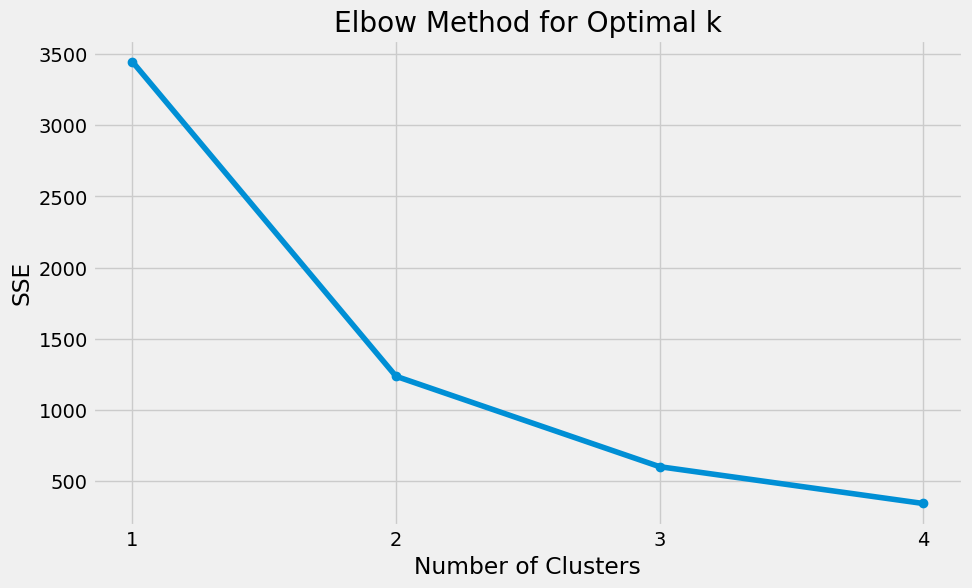

<Figure size 640x480 with 0 Axes>

In [13]:
X = np.array(df_cluster)

# A list holds the SSE values for each k
sse = []
for k in range(1, try_clusters):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit_predict(X)
    sse.append(kmeans.inertia_)

plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))
plt.plot(range(1, try_clusters), sse, marker='o')
plt.xticks(range(1, try_clusters))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method for Optimal k")
plt.show()
chart_name = f"elbow_method_try_clusters_{try_clusters}"
chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", chart_name + ".png")
plt.savefig(chart_path, dpi=900, bbox_inches='tight')

In [14]:
kl = KneeLocator(range(1, try_clusters), sse, curve="convex", direction="decreasing")
print("Elbow method: optimal number of clusters is", kl.elbow)

Elbow method: optimal number of clusters is 2


### The silhouette coefficient
The silhouette coefficient is a measure of cluster cohesion and separation. It quantifies how well a data point fits into its assigned cluster based on two factors:

- How close the data point is to other points in the cluster
- How far away the data point is from points in other clusters

Silhouette coefficient values range between -1 and 1. Larger numbers indicate that samples are closer to their clusters than they are to other clusters.

Silhouette coefficients:
   Silhouette Score
2          0.570296
3          0.537237
4          0.499106


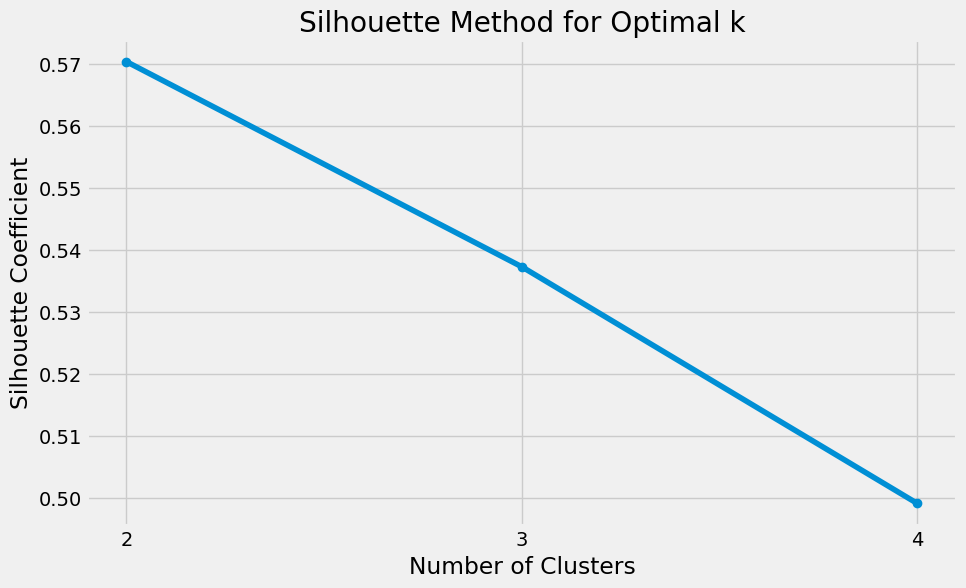

Silhouette coefficients: optimal number of clusters is 2


<Figure size 640x480 with 0 Axes>

In [16]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, try_clusters):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_coefficients.append(score)
    
print("Silhouette coefficients:")
print(pd.DataFrame(silhouette_coefficients, index=range(2, try_clusters), columns=['Silhouette Score']))
    
plt.style.use("fivethirtyeight")
plt.figure(figsize=(10, 6))
plt.plot(range(2, try_clusters), silhouette_coefficients, marker='o')
plt.xticks(range(2, try_clusters))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.title("Silhouette Method for Optimal k")
plt.show()

chart_name = f"silhouette_method_try_clusters_{try_clusters}"
chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", chart_name + ".png")
plt.savefig(chart_path, dpi=900, bbox_inches='tight')

df_sil_coeff = pd.DataFrame(silhouette_coefficients).reset_index()
optimal_silhouette_coefficients = df_sil_coeff.loc[df_sil_coeff[0] == max(silhouette_coefficients), 'index'].values[0] + 2
print("Silhouette coefficients: optimal number of clusters is", optimal_silhouette_coefficients)

## ✅ CHECK POINT with the data scientist: cluster using the chosen number of clusters

In [17]:
# Choose the number of clusters based on the analysis above
chosen_clusters = max(kl.elbow, optimal_silhouette_coefficients)
print(f"Chosen number of clusters: {chosen_clusters}")

Chosen number of clusters: 2


In [18]:
kmeans = KMeans(n_clusters=chosen_clusters, **kmeans_kwargs)
identified_clusters = kmeans.fit_predict(X)

df_cluster.loc[:, 'cluster'] = identified_clusters 
print(f"Clustering complete. Shape: {df_cluster.shape}")
df_cluster.head()

Clustering complete. Shape: (38, 104)


WEEK_START_DT,2023-04-03 00:00:00,2023-04-10 00:00:00,2023-04-17 00:00:00,2023-04-24 00:00:00,2023-05-01 00:00:00,2023-05-08 00:00:00,2023-05-15 00:00:00,2023-05-22 00:00:00,2023-05-29 00:00:00,2023-06-05 00:00:00,...,2025-01-20 00:00:00,2025-01-27 00:00:00,2025-02-03 00:00:00,2025-02-10 00:00:00,2025-02-17 00:00:00,2025-02-24 00:00:00,2025-03-03 00:00:00,2025-03-10 00:00:00,2025-03-17 00:00:00,cluster
STORE_LOCATION_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.341401,0.169970,0.186726,0.282201,0.145041,0.431175,0.504644,0.372403,0.345862,0.259166,...,0.096437,-0.024256,0.174515,0.059090,0.032629,0.176408,-0.175637,-0.059180,0.179194,1
2,-0.132050,0.508318,0.618696,0.444962,0.435407,0.799890,0.375559,0.480887,0.628091,0.793742,...,0.506245,0.344802,0.549206,0.435720,0.490178,0.725554,0.268298,0.283184,0.654831,1
3,-0.146304,0.852482,0.528257,0.457942,0.479592,0.764824,0.500178,0.485770,0.440331,0.339456,...,0.445780,0.495080,0.454094,0.281286,0.390547,0.372771,0.267303,0.249897,0.447055,1
4,-0.625823,-0.128672,-0.104631,-0.287047,-0.209134,-0.028268,-0.096050,-0.139051,-0.081808,-0.161056,...,-0.293709,-0.310284,-0.261208,-0.253292,-0.217402,-0.276690,-0.539006,-0.208158,0.003007,0
5,0.125368,0.572115,0.567537,0.455936,0.722501,1.120305,0.790045,0.774380,0.848314,0.758708,...,0.535931,0.521878,0.508996,0.229012,0.244821,0.572935,0.408347,0.297599,0.611616,1


In [19]:
print("List of IDs for profiling:")
print(list_id_profiling)

List of IDs for profiling:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(18), np.int64(19), np.int64(21), np.int64(22), np.int64(23), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(46), np.int64(48), np.int64(49)]


In [20]:
dict_cluster = {}
dict_cluster['regular'] = {}
for c in range(0, len(list_id_profiling)):
    if list_id_profiling[c] in df_cluster.index:
        dict_cluster['regular'][c] = int(df_cluster.loc[df_cluster.index == list_id_profiling[c], 'cluster'].unique()[0])

count = 0
for cluster in range(0, chosen_clusters):
    num_cluster = len(df_cluster.loc[df_cluster['cluster'] == cluster].index.tolist())
    count = count + num_cluster
    print("Unique ids in cluster", cluster, 'are', num_cluster)
    
print("\nTotal unique ids clustered:", count)

Unique ids in cluster 0 are 24
Unique ids in cluster 1 are 14

Total unique ids clustered: 38


## Plotting clustered regular series

In [21]:
df_cluster.reset_index().head()

WEEK_START_DT,STORE_LOCATION_ID,2023-04-03 00:00:00,2023-04-10 00:00:00,2023-04-17 00:00:00,2023-04-24 00:00:00,2023-05-01 00:00:00,2023-05-08 00:00:00,2023-05-15 00:00:00,2023-05-22 00:00:00,2023-05-29 00:00:00,...,2025-01-20 00:00:00,2025-01-27 00:00:00,2025-02-03 00:00:00,2025-02-10 00:00:00,2025-02-17 00:00:00,2025-02-24 00:00:00,2025-03-03 00:00:00,2025-03-10 00:00:00,2025-03-17 00:00:00,cluster
0,1,-0.341401,0.169970,0.186726,0.282201,0.145041,0.431175,0.504644,0.372403,0.345862,...,0.096437,-0.024256,0.174515,0.059090,0.032629,0.176408,-0.175637,-0.059180,0.179194,1
1,2,-0.132050,0.508318,0.618696,0.444962,0.435407,0.799890,0.375559,0.480887,0.628091,...,0.506245,0.344802,0.549206,0.435720,0.490178,0.725554,0.268298,0.283184,0.654831,1
2,3,-0.146304,0.852482,0.528257,0.457942,0.479592,0.764824,0.500178,0.485770,0.440331,...,0.445780,0.495080,0.454094,0.281286,0.390547,0.372771,0.267303,0.249897,0.447055,1
3,4,-0.625823,-0.128672,-0.104631,-0.287047,-0.209134,-0.028268,-0.096050,-0.139051,-0.081808,...,-0.293709,-0.310284,-0.261208,-0.253292,-0.217402,-0.276690,-0.539006,-0.208158,0.003007,0
4,5,0.125368,0.572115,0.567537,0.455936,0.722501,1.120305,0.790045,0.774380,0.848314,...,0.535931,0.521878,0.508996,0.229012,0.244821,0.572935,0.408347,0.297599,0.611616,1


### Reshaping data frame for plots

In [22]:
df_to_plot = pd.melt(df_cluster.reset_index(), id_vars=[unique_id, 'cluster'], var_name=date_var, value_name='y_std')
df_to_plot[date_var] = pd.to_datetime(df_to_plot[date_var])
df_to_plot = pd.merge(df_to_plot, right=df[[unique_id, date_var, y]].drop_duplicates(), on=[unique_id, date_var], how='left', validate='1:1')
print(f"Data for plotting prepared: {len(df_to_plot)} rows")
df_to_plot.head()

Data for plotting prepared: 3914 rows


,STORE_LOCATION_ID,cluster,WEEK_START_DT,y_std,TOTAL_NET_SALES
0,1,1,2023-04-03,-0.341401,522814.849132
1,2,1,2023-04-03,-0.132050,562611.757736
2,3,1,2023-04-03,-0.146304,559901.967704
3,4,0,2023-04-03,-0.625823,468747.448057
4,5,1,2023-04-03,0.125368,611545.761696


In [23]:
print("Num of regular time series clusterized:", df_to_plot[[unique_id, 'cluster']].drop_duplicates().groupby('cluster').count().sum()[0])
df_to_plot[[unique_id, 'cluster']].drop_duplicates().groupby('cluster').count()

Num of regular time series clusterized: 38


C:\Users\mabellani\AppData\Local\Temp\ipykernel_34316\4034986825.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Num of regular time series clusterized:", df_to_plot[[unique_id, 'cluster']].drop_duplicates().groupby('cluster').count().sum()[0])


,STORE_LOCATION_ID
cluster,
0,24
1,14


### ✅ CHECK POINT with the data scientist: plot max 10 time series per cluster

Plot up to 10 time series per cluster chosen randomly, so that the data scientist can look at them and maybe give you hints on the drivers of consumption, such as weather data or promotional marketing campaigns.

These information are going to be useful for the feature engineering step.


=== Plotting cluster: 0 ===
Plotting 10 randomly chosen ids in cluster for visualization


<Figure size 1500x700 with 0 Axes>

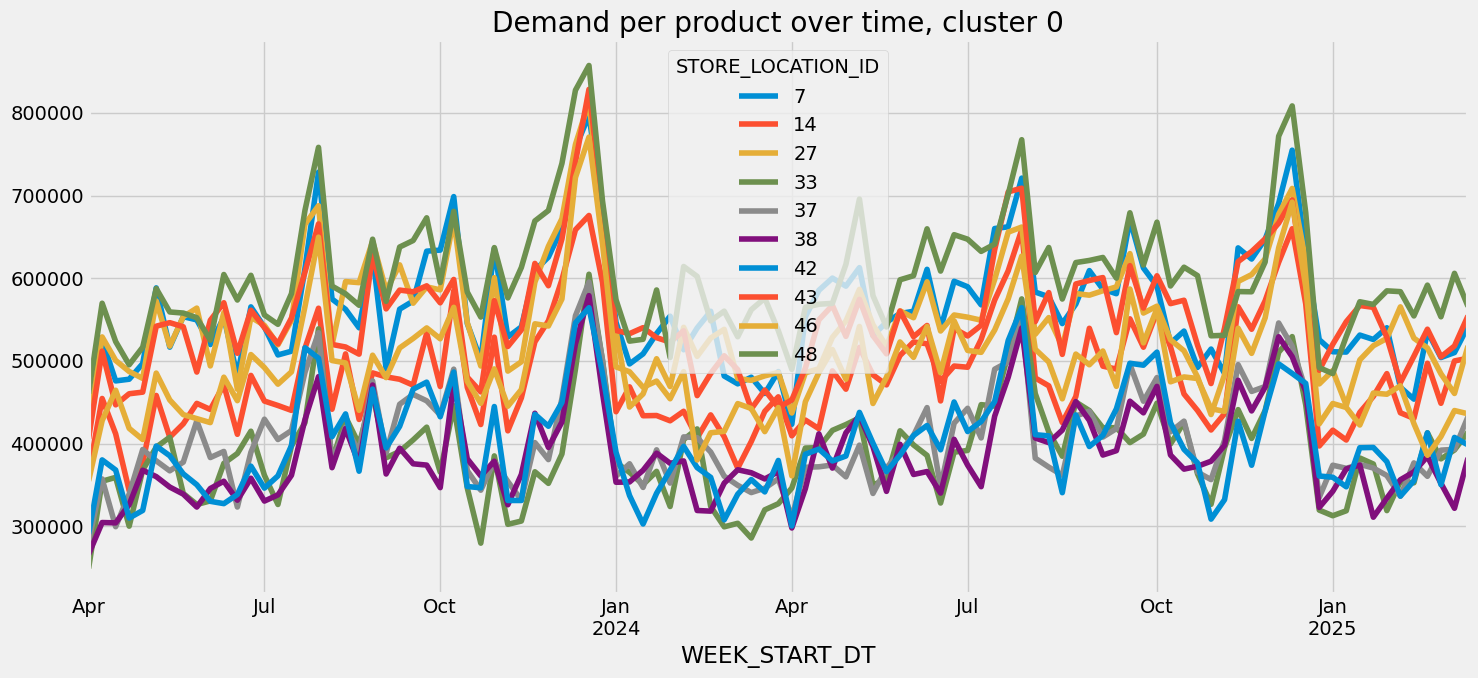

Creating plot for id: 37 (1 of 10)
Creating plot for id: 46 (2 of 10)
Creating plot for id: 43 (3 of 10)
Creating plot for id: 7 (4 of 10)
Creating plot for id: 48 (5 of 10)
Creating plot for id: 14 (6 of 10)
Creating plot for id: 33 (7 of 10)
Creating plot for id: 27 (8 of 10)
Creating plot for id: 38 (9 of 10)
Creating plot for id: 42 (10 of 10)

=== Plotting cluster: 1 ===
Plotting 10 randomly chosen ids in cluster for visualization


<Figure size 640x480 with 0 Axes>

<Figure size 1500x700 with 0 Axes>

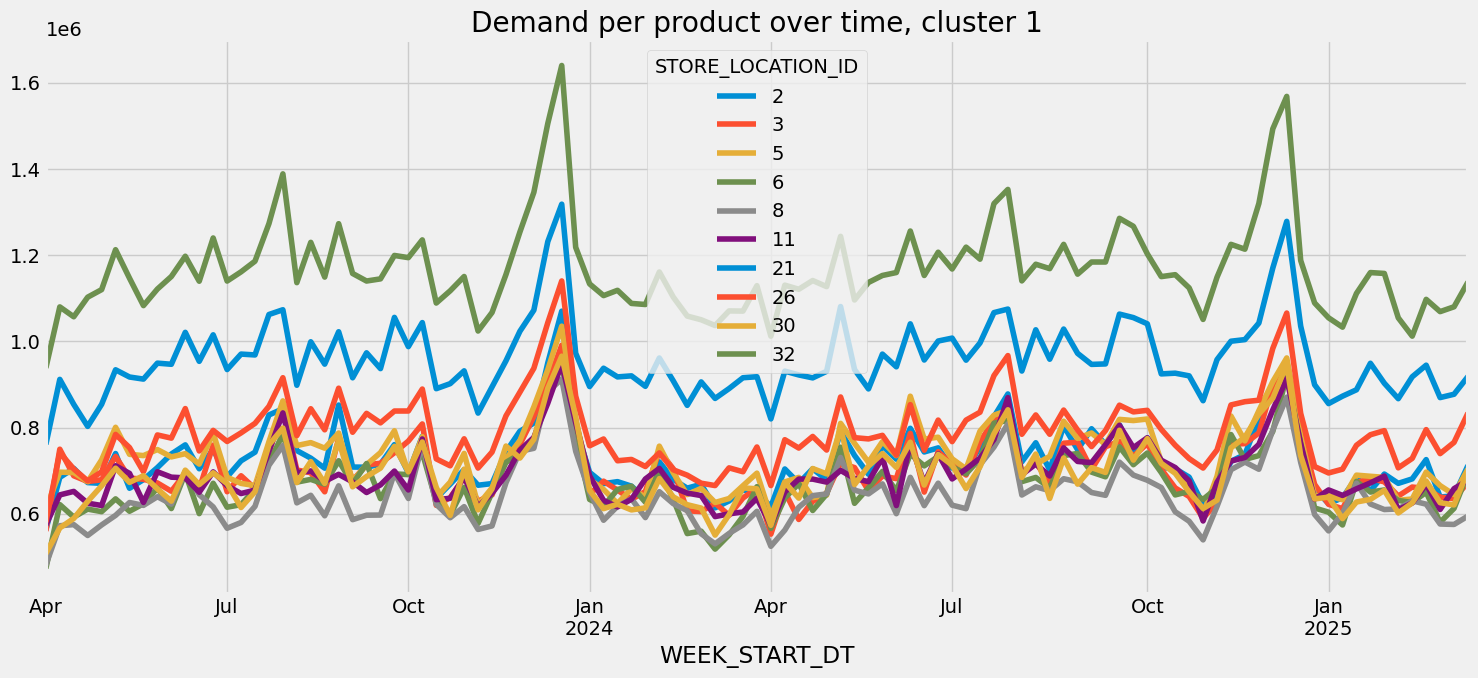

Creating plot for id: 21 (1 of 10)
Creating plot for id: 5 (2 of 10)
Creating plot for id: 26 (3 of 10)
Creating plot for id: 8 (4 of 10)
Creating plot for id: 6 (5 of 10)
Creating plot for id: 30 (6 of 10)
Creating plot for id: 32 (7 of 10)
Creating plot for id: 3 (8 of 10)
Creating plot for id: 11 (9 of 10)
Creating plot for id: 2 (10 of 10)

✅ Total plots created: 20


<Figure size 640x480 with 0 Axes>

In [26]:
# Store plots in a dictionary for display
cluster_plots = {}
import random
random.seed(sample_seed_kmeans)

for cluster in sorted(list(df_to_plot['cluster'].unique())):
    print(f'\n=== Plotting cluster: {cluster} ===')
    list_ids_in_cluster = list(df_to_plot.loc[df_to_plot['cluster'] == cluster, unique_id].unique())
    plot_ids = list_ids_in_cluster if len(list_ids_in_cluster) <= 10 else random.sample(list_ids_in_cluster, 10)
    
    # Create overview plot for cluster
    plt.figure(figsize=(15, 7))
    if len(list_ids_in_cluster) > 10:
        print('Plotting 10 randomly chosen ids in cluster for visualization')
    df_to_plot.loc[df_to_plot[unique_id].isin(plot_ids), ].groupby([unique_id, date_var])[y].apply(np.mean).reset_index().pivot(index=date_var, columns=unique_id, values=y).plot(figsize=(15,7))
    plt.title(f'Demand per product over time, cluster {cluster}')
    plt.tight_layout()
    plt.show()
    chart_name = f"demand_per_product_cluster_{cluster}"
    chart_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", chart_name + ".png")
    plt.savefig(chart_path, dpi=900, bbox_inches='tight')
    
    # Create individual interactive plots
    count = 1
    for i in plot_ids:
        print(f'Creating plot for id: {i} ({count} of {len(plot_ids)})')
        
        chart_title = f"{unique_id} {i} - Profile regular cluster {cluster}"
        plot = sliding_line_plot(df_to_plot, unique_id, y, i, chart_title=chart_title)
        
        save_path = os.path.join(root_path, "data", LOCAL_FOLDER, "charts", f"{unique_id}_{i}_cluster_{cluster}.html")
        plot.write_html(save_path)
        
        # Store plot for optional display
        cluster_plots[f"{unique_id}_{i}_cluster_{cluster}"] = plot
        count += 1
        
print(f"\n✅ Total plots created: {len(cluster_plots)}")

In [27]:
# Display a sample plot (first one from each cluster)
for cluster in sorted(list(df_to_plot['cluster'].unique())):
    keys_for_cluster = [k for k in cluster_plots.keys() if k.endswith(f"_cluster_{cluster}")]
    if not keys_for_cluster:
        print(f"\nNo stored plot found for Cluster {cluster}")
        continue
    plot_key = keys_for_cluster[0]
    print(f"\nSample plot for Cluster {cluster}:")
    cluster_plots[plot_key].show()


Sample plot for Cluster 0:



Sample plot for Cluster 1:


⚠️ Save also the additional information on potential drivers the data scientist is providing you with.

# Saving
The output is a dataframe with the same information as in df_profiling, with an additional column "cluster" with the cluster number only for regular profiles

In [30]:
df_profiling_clustering = pd.merge(
    df_profiling, 
    df_cluster[['cluster']].reset_index().rename(columns={'index': unique_id}), 
    on=unique_id, 
    how='left', 
    validate='1:1'
)
print(f"Merged profiling with clusters: {len(df_profiling_clustering)} rows")

# Pivot table showing profile vs cluster distribution
pd.pivot_table(df_profiling_clustering, index='profile', columns='cluster', values=unique_id, aggfunc='count', fill_value=0).T
print("Total number of series:", pd.pivot_table(df_profiling_clustering, index='profile', columns='cluster', values=unique_id, aggfunc='count', fill_value=0).T.sum().sum())

df_profiling_clustering['profile_cluster'] = df_profiling_clustering['profile']
df_profiling_clustering.loc[df_profiling_clustering['profile'] == 'regular', 'profile_cluster'] = df_profiling_clustering['cluster']
df_profiling_clustering.drop(columns=['profile', 'cluster'], inplace=True)
df_profiling_clustering['profile_cluster'] = df_profiling_clustering['profile_cluster'].astype(str)
df_profiling_clustering.head()

Merged profiling with clusters: 50 rows
Total number of series: 38


,STORE_LOCATION_ID,type,k,low_demand,cv2,adi,sddi,profile_cluster
0,1,perc_quant_999,103,8940.914706,0.008781,2902.041137,55729.031602,1.0
1,2,perc_quant_999,103,10579.725185,0.007291,4899.035184,60100.748047,1.0
2,3,perc_quant_999,103,9874.136855,0.008653,2205.769570,65536.257704,1.0
3,4,perc_quant_999,103,8020.743506,0.009046,2260.903782,52457.242364,0.0
4,5,perc_quant_999,103,10278.655113,0.009100,1648.101756,65918.562441,1.0


In [31]:
# Save results to Lakehouse
try:
    df_profiling_clustering_spark = spark.createDataFrame(df_profiling_clustering)
    df_profiling_clustering_spark.write.mode("overwrite").saveAsTable(f"{LAKEHOUSE_NAME}.{OUTPUT_TABLE}")
    print(f"✅ Results saved to Lakehouse table: {LAKEHOUSE_NAME}.{OUTPUT_TABLE}")
except:
    df_profiling_clustering.to_parquet(f"{root_path}/data/{LOCAL_FOLDER}/{OUTPUT_TABLE}.parquet", index=False)
    print(f"❌ Error saving results to Lakehouse table")
    print("Saving to local file instead.")
    print(f"✅ df_features saved locally at: {root_path}/data/{OUTPUT_TABLE}.parquet") 

❌ Error saving results to Lakehouse table
Saving to local file instead.
✅ df_features saved locally at: c:\Users\mabellani\OneDrive - Microsoft\Documents\REPOSITORY\time-series-forecasting-accelerator-agent/data/df_profiling_clustering.parquet
